<a href="https://colab.research.google.com/github/rithvikraj-hub/FUTURE_ML_03/blob/main/resume_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Resume.csv (2).zip to Resume.csv (2).zip


Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')
Top Ranked Candidates:
      Resume_ID  Match_Score
1218       1219    19.294151
1762       1763    18.586421
1142       1143    16.704944
2153       2154    15.342452
243         244    14.778241
1303       1304    14.455975
1339       1340    14.036493
120         121    13.473024
280         281    13.217390
926         927    13.064617


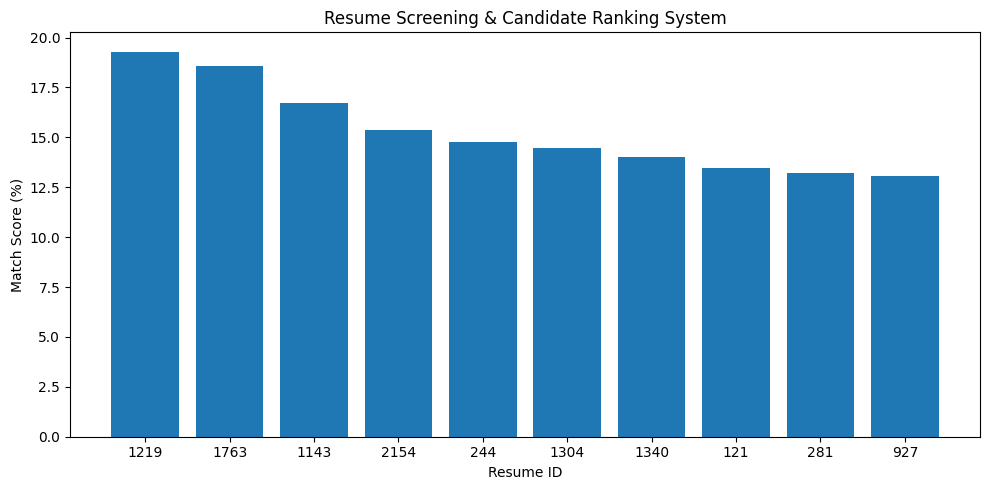

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Unzip the uploaded file
zip_file_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall()

# Assuming the CSV file inside the zip is named 'Resume.csv'
# You might need to adjust this if the name is different after unzipping
csv_file_name = 'Resume.csv' # Or inspect os.listdir() to find the correct name

# Load Resume Dataset
df = pd.read_csv(csv_file_name)

# Check column names
print(df.columns)

# Job Description
job_description = """
Python Developer with Machine Learning,
SQL, Data Analysis and NLP skills
"""

# Resume Text
resumes = df["Resume_str"]

# Combine JD and Resumes
documents = [job_description] + resumes.astype(str).tolist()

# Convert text into numerical features
vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = vectorizer.fit_transform(documents)

# Calculate Similarity Scores
similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
)

# Ranking Table
results = pd.DataFrame({
    "Resume_ID": range(1, len(resumes) + 1),
    "Match_Score": similarity_scores[0] * 100
})

# Sort by Highest Match
results = results.sort_values(
    by="Match_Score",
    ascending=False
)

print("Top Ranked Candidates:")
print(results.head(10))

# Visualization
plt.figure(figsize=(10, 5))

top_candidates = results.head(10)

plt.bar(
    top_candidates["Resume_ID"].astype(str),
    top_candidates["Match_Score"]
)

plt.xlabel("Resume ID")
plt.ylabel("Match Score (%)")
plt.title("Resume Screening & Candidate Ranking System")

plt.tight_layout()

plt.savefig("resume_ranking.png")

plt.show()

In [7]:
import os
import shutil

# Create Project Folders
os.makedirs("FUTURE_ML_03/data", exist_ok=True)
os.makedirs("FUTURE_ML_03/images", exist_ok=True)
os.makedirs("FUTURE_ML_03/notebooks", exist_ok=True)

print("Folders Created Successfully")

# Copy Dataset
shutil.copy(
    csv_file_name, # Use the correct filename variable
    "FUTURE_ML_03/data/" + csv_file_name # Use the correct filename for the destination
)

# Copy Generated Graph
shutil.copy(
    "resume_ranking.png",
    "FUTURE_ML_03/images/resume_ranking.png"
)



Folders Created Successfully


'FUTURE_ML_03/images/resume_ranking.png'